In [2]:
import os
os.chdir('../../../../../..')

In [3]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN, KMeans
from kmedoids import KMedoids
from hdbscan import HDBSCAN
from umap import UMAP

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection,benchmark_functional_groups, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster,evaluate_hdbscan_grid

projection_method = "UMAP"

In [14]:
qm9 = QM9Dataset(limit=None, descriptors=["morgan"])
#qm9 = QM9Dataset(limit=None)
df = qm9.load()
X = np.array(df["morgan_fingerprint"].to_list())

2026-05-22 12:53:36.316 | INFO     | src.datasets:_load_full_qm9_df:817 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-22 12:53:36.620 | INFO     | src.datasets:_sample_qm9_df:1000 - QM9 sampling complete: strategy=stratified, requested_limit=None, returned_rows=124232, sampling on columns=['num_atoms', 'gap'].
2026-05-22 12:53:36.621 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=124232).
2026-05-22 12:53:36.621 | INFO     | src.features:compute_morgan_fingerprints:225 - Computing Morgan Fingerprints (Radius=2, Size=2048)...
2026-05-22 12:57:17.893 | INFO     | src.datasets:_add_requested_descriptors:213 - Added descriptor column(s): ['morgan_fingerprint']


# Hypo 0 
- is syntax independent

In [5]:
import random
from time import time
import numpy as np
import polars as pl
from rdkit import Chem
from rdkit.Chem import AllChem
from tqdm import tqdm


# -------------------------------------------------------------------------
# 1. OPTIMIZED REPRESENTATION EXTRACTION
# -------------------------------------------------------------------------
def compute_morgan_bit_vect(smiles: str, radius: int, n_bits: int = 2048) -> np.ndarray:
    """Generates an explicit boolean numpy array for a Morgan Fingerprint."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(n_bits, dtype=bool)
    
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    
    # Pre-allocating directly to int8/bool eliminates wasteful array castings
    arr = np.zeros((n_bits,), dtype=np.int8)
    Chem.DataStructs.ConvertToNumpyArray(fp, arr)
    return arr.astype(bool)


# -------------------------------------------------------------------------
# 2. RANDOMIZED PATH GENERATION
# -------------------------------------------------------------------------
def generate_smiles_variants(smiles_str: str, num_variants: int = 20, timeout: float = 1.0) -> list[str]:
    """
    Generates unique, non-canonical, randomized SMILES variants for a molecule.
    These strings have completely different syntax but identical graph topology.
    """
    mol = Chem.MolFromSmiles(smiles_str)
    if not mol:
        return []
    
    # Strip explicit hydrogens to keep the syntax shuffling clean
    mol = Chem.RemoveHs(mol)
    
    # We use a set to ensure all generated string variations are unique syntactically
    unique_syntax_variants = set()
    start_time = time()
    
    while len(unique_syntax_variants) < num_variants:
        if (time() - start_time) > timeout:
            break
        
        # doRandom=True shuffles the root atom and DFS traversal order
        v = Chem.MolToSmiles(mol, doRandom=True, canonical=False)
        unique_syntax_variants.add(v)
        
    return list(unique_syntax_variants)


# -------------------------------------------------------------------------
# 3. SAMPLING & EXECUTION ENGINE
# -------------------------------------------------------------------------
# Target long SMILES from your Polars DataFrame (longer strings = more syntax variations)
long_smiles = [s for s in df["canonical_smiles"].to_list() if len(s) > 50]

if len(long_smiles) < 20:
    raise ValueError("Not enough long SMILES strings (>50 chars) in dataset. Lower the length constraint.")

sample_pool = random.sample(long_smiles, 20)

target_molecule_count = 0
invariance_results = []

print(f"Beginning Syntax-Independence Test across {len(sample_pool)} diverse molecular graphs...\n")

for origin_smiles in tqdm(sample_pool, desc="Testing Path Invariance"):
    # Generate 20 wildly different string paths for the same 3D structure
    syntax_variants = generate_smiles_variants(origin_smiles, num_variants=20)
    
    if len(syntax_variants) < 20:
        continue  # Skip if the molecule is too small/symmetric to yield 20 unique paths
        
    # Generate fingerprints for all 20 unique string syntaxes
    fingerprints = [compute_morgan_bit_vect(s, radius=2, n_bits=2048) for s in syntax_variants]
    
    # --- THE CRITICAL MATHEMATICAL PROOF STEP ---
    # Compare all 19 variations against the first variation vector
    base_fp = fingerprints[0]
    all_identical = all(np.array_equal(base_fp, comp_fp) for comp_fp in fingerprints[1:])
    
    invariance_results.append({
        "canonical_smiles": Chem.MolToSmiles(Chem.MolFromSmiles(origin_smiles)),
        "unique_syntax_strings_tested": len(syntax_variants),
        "is_perfectly_invariant": all_identical
    })
    
    target_molecule_count += 1
    if target_molecule_count >= 20:
        break

# -------------------------------------------------------------------------
# 4. VERIFICATION REPORT
# -------------------------------------------------------------------------
df_proof = pl.DataFrame(invariance_results)
print("\n--- SYNTAX INDEPENDENCE VERIFICATION REPORT ---")
print(df_proof)

total_passed = df_proof["is_perfectly_invariant"].sum()
if total_passed == len(df_proof):
    print(f"\n✅ PROOF SUCCESSFUL: 100% of the tested molecules ({total_passed}/{len(df_proof)}) yielded "
          f"identical Morgan Fingerprint vectors across every unique string variation.")
else:
    print("\n❌ PROOF FAILED: Discrepancies found in syntax mapping.")

Beginning Syntax-Independence Test across 20 diverse molecular graphs...



Testing Path Invariance:  95%|█████████▌| 19/20 [00:00<00:00, 209.02it/s]


--- SYNTAX INDEPENDENCE VERIFICATION REPORT ---
shape: (20, 3)
┌─────────────────────────────────┬──────────────────────────────┬────────────────────────┐
│ canonical_smiles                ┆ unique_syntax_strings_tested ┆ is_perfectly_invariant │
│ ---                             ┆ ---                          ┆ ---                    │
│ str                             ┆ i64                          ┆ bool                   │
╞═════════════════════════════════╪══════════════════════════════╪════════════════════════╡
│ C[N@@H+]1[C@H]2[C@H]3[C@@H]1[C… ┆ 20                           ┆ true                   │
│ O[C@@H]1[C@@H]2[C@@H]3N[C@H]4[… ┆ 20                           ┆ true                   │
│ C1O[C@@H]2[C@H]3[C@@H]4[C@H]5[… ┆ 20                           ┆ true                   │
│ O[C@@H]1[C@@H]2[CH-][C@H]3[C@@… ┆ 20                           ┆ true                   │
│ [NH-][CH+]O[C@@]12[C@@H]3[C@H]… ┆ 20                           ┆ true                   │
│ …             

Generating randomized syntax blocks...
Computing pairwise distance matrices...


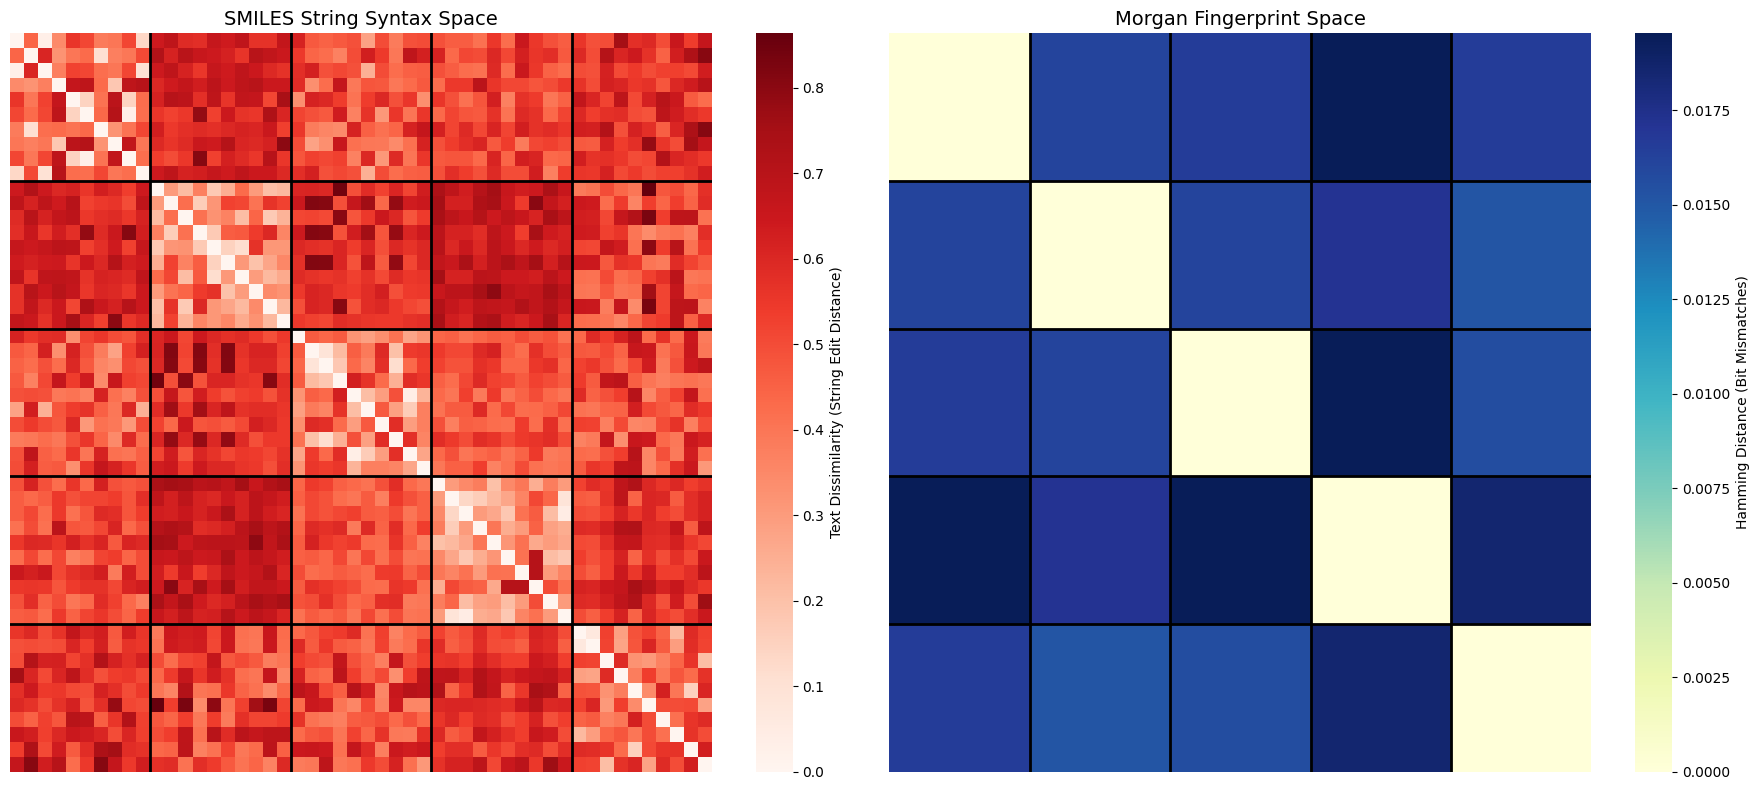

In [6]:
import random
from time import time
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.metrics import pairwise_distances

# 1. Setup sampling from your Polars DataFrame
long_smiles = [s for s in df["smiles"].to_list() if len(s) > 50]
sample_pool = random.sample(long_smiles, 5) # Use 5 molecules for a clean, readable plot

num_variants = 10
all_variants = []
labels = []
molecule_ids = []

print("Generating randomized syntax blocks...")
for idx, origin_smiles in enumerate(sample_pool):
    mol = Chem.RemoveHs(Chem.MolFromSmiles(origin_smiles))
    syntax_variants = set()
    start_time = time()
    
    # Generate unique syntax variants
    while len(syntax_variants) < num_variants:
        if (time() - start_time) > 1.0:
            break
        v = Chem.MolToSmiles(mol, doRandom=True, canonical=False)
        syntax_variants.add(v)
        
    variants_list = list(syntax_variants)
    all_variants.extend(variants_list)
    # Track labels for plotting
    labels.extend([f"Mol {idx+1} (Var {i+1})" for i in range(len(variants_list))])
    molecule_ids.extend([idx] * len(variants_list))

# 2. Compute Morgan Fingerprints for all variants
def get_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    arr = np.zeros((2048,), dtype=np.int8)
    Chem.DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

fp_matrix = np.array([get_fp(s) for s in all_variants])

import difflib
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances

# -------------------------------------------------------------------------
# 3. COMPUTE GENUINE DISTANCE MATRICES
# -------------------------------------------------------------------------
print("Computing pairwise distance matrices...")

# Fingerprints: Normalized Hamming distance (percentage of mismatched bits)
fp_distances = pairwise_distances(fp_matrix, metric="hamming")

# Raw Text Strings: Real string distance matrix using SequenceMatcher
# (1.0 - ratio) gives a true text dissimilarity score between 0.0 (identical text) and 1.0
num_all_variants = len(all_variants)
text_matrix = np.zeros((num_all_variants, num_all_variants))

for i in range(num_all_variants):
    for j in range(num_all_variants):
        if i == j:
            text_matrix[i, j] = 0.0
        elif j > i:  # Symmetric matrix optimization
            ratio = difflib.SequenceMatcher(None, all_variants[i], all_variants[j]).ratio()
            dissimilarity = 1.0 - ratio
            text_matrix[i, j] = dissimilarity
            text_matrix[j, i] = dissimilarity

# -------------------------------------------------------------------------
# 4. PLOTTING SIDE-BY-SIDE COMPARISON
# -------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Left Plot: Text Space Chaos
sns.heatmap(text_matrix, ax=ax1, cmap="Reds", cbar_kws={'label': 'Text Dissimilarity (String Edit Distance)'},
            xticklabels=False, yticklabels=False)
ax1.set_title("SMILES String Syntax Space", fontsize=14)

# Right Plot: Fingerprint Invariance Proof
sns.heatmap(fp_distances, ax=ax2, cmap="YlGnBu", cbar_kws={'label': 'Hamming Distance (Bit Mismatches)'},
            xticklabels=False, yticklabels=False)
ax2.set_title("Morgan Fingerprint Space", fontsize=14)

# Draw black grid lines separating different molecular families
for i in range(1, len(sample_pool)):
    ax1.axhline(i * num_variants, color='black', lw=2)
    ax1.axvline(i * num_variants, color='black', lw=2)
    ax2.axhline(i * num_variants, color='black', lw=2)
    ax2.axvline(i * num_variants, color='black', lw=2)

plt.tight_layout()
plt.show()

# Hypothesis 1
- Can destiniush between aromatic, cyclic and acyclic

In [15]:
df['structure_class'].value_counts()

structure_class,count
str,u32
"""Acyclic""",13390
"""Aliphatic Ring""",89912
"""Aromatic""",20930


In [23]:
# choose 100 of each structure type
df_acyclic = df.filter(pl.col("structure_class") == "Acyclic").sample(n=100, seed=42)
df_aromatic = df.filter(pl.col("structure_class") == "Aromatic").sample(n=100, seed=42)
df_rings = df.filter(pl.col("structure_class") == "Aliphatic Ring").sample(n=100, seed=42)
df_sample = pl.concat([df_acyclic, df_aromatic, df_rings])

# calculate distance matrix for the sample using Jaccard distance
from sklearn.metrics import pairwise_distances
# labels are 1 for aromatic, 2 for aliphatic ring, and 0 for acyclic use polars
labels = [1 if x == "Aromatic" else (2 if x == "Aliphatic Ring" else 0) for x in df_sample["structure_class"].to_list()]

dist_matrix = pairwise_distances(np.array(df_sample["morgan_fingerprint"].to_list()), metric="jaccard")

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/metrics/pairwise.py:2459: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


In [24]:
import numpy as np
import polars as pl
from sklearn.metrics import pairwise_distances, silhouette_score

# 1. Memory-safe extraction of binary Morgan Fingerprints (bypasses .to_list() overhead)
X = np.vstack(df_sample["morgan_fingerprint"].to_numpy()).astype(bool)

# 2. Efficiently map labels using native Polars expressions instead of a Python loop
labels = (
    df_sample.select(
        pl.when(pl.col("structure_class") == "Aromatic").then(1)
        .when(pl.col("structure_class") == "Aliphatic Ring").then(2)
        .otherwise(0)
    ).to_numpy().flatten()
)

# 3. Calculate distance matrix using Jaccard distance
dist_matrix = pairwise_distances(X, metric="jaccard")

# 4. Calculate the Silhouette Score using your precomputed distance matrix
score = silhouette_score(dist_matrix, labels, metric="precomputed")

print(f"Morgan Fingerprint Space Silhouette Score: {score:.4f}")

Morgan Fingerprint Space Silhouette Score: 0.0550


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


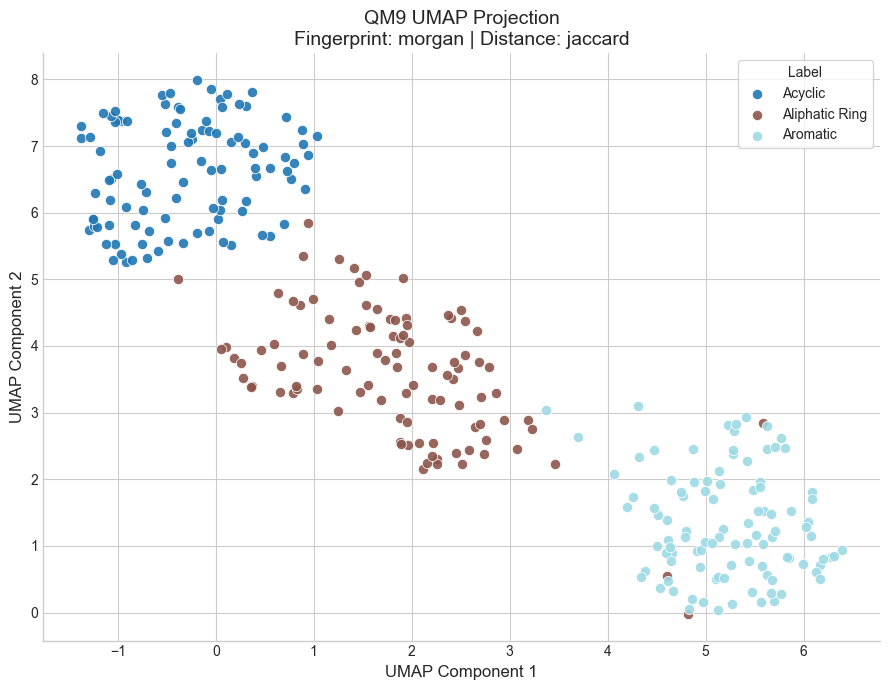

2026-05-20 09:46:14.848 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:628 - Saved UMAP projection plot to figures/qm9/clustering/jaccard/morgan/umap_projection.png


In [ ]:
_=plot_distance_matrix_projection(dist_matrix, fingerprint="morgan", projection_method='UMAP', labels=df_sample["structure_class"].to_list(), distance_metric="jaccard")

ARI Score for Agglomerative Clustering: 0.9220
ARI Score for K-Medoids Clustering: 0.4637


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden t

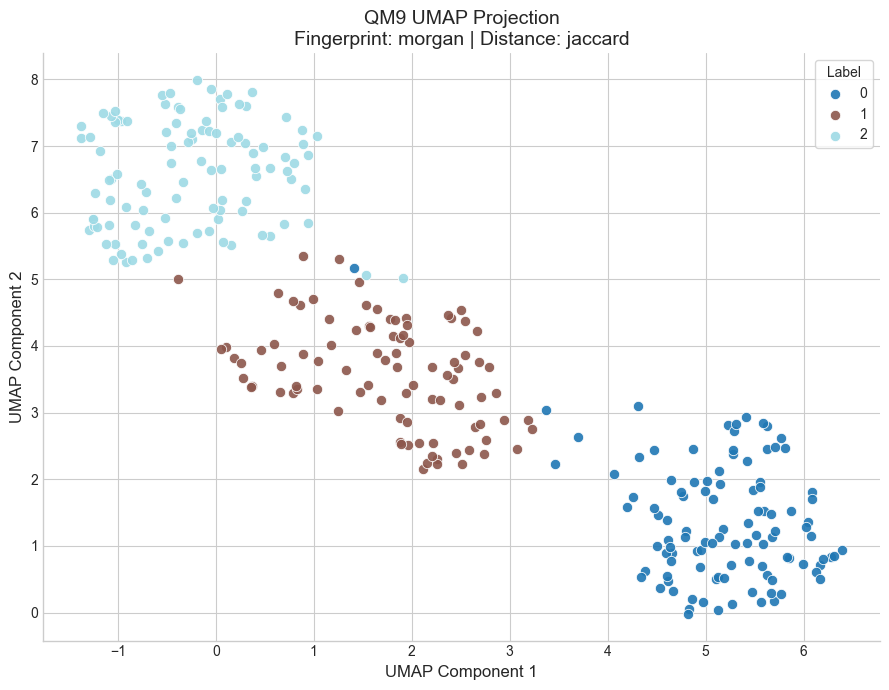

2026-05-20 09:46:15.892 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:628 - Saved UMAP projection plot to figures/qm9/clustering/jaccard/morgan/umap_projection.png


In [ ]:
# agg clustering will be able to find the clusters, but it will not be perfect because of the noise in the data
agg_clust = AgglomerativeClustering(n_clusters=3, metric='precomputed', linkage='average')
predicted_labels = agg_clust.fit_predict(dist_matrix)
from sklearn.metrics import adjusted_rand_score
ari_score = adjusted_rand_score(labels, predicted_labels)
print(f"ARI Score for Agglomerative Clustering: {ari_score:.4f}")

kmedoids_clust = KMedoids(n_clusters=3, metric='precomputed', random_state=42)
predicted_labels_kmedoids = kmedoids_clust.fit_predict(dist_matrix)
ari_score_kmedoids = adjusted_rand_score(labels, predicted_labels_kmedoids)
print(f"ARI Score for K-Medoids Clustering: {ari_score_kmedoids:.4f}")

# plot the UMAP projection of the distance matrix
coords = UMAP(metric='precomputed', random_state=42).fit_transform(dist_matrix)
_=plot_distance_matrix_projection(dist_matrix, fingerprint="morgan", projection_method='UMAP', labels=predicted_labels, distance_metric="jaccard")

In [ ]:
create_chemiscope_viewer(df_sample, dist_matrix, predicted_labels, 'UMAP')

2026-05-20 09:46:15.912 | INFO     | src.helper_functions:create_chemiscope_viewer:1163 - Running UMAP dimensionality reduction...
2026-05-20 09:46:15.912 | INFO     | src.helper_functions:create_chemiscope_viewer:1172 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-20 09:46:18.076 | INFO     | src.helper_functions:create_chemiscope_viewer:1212 - Projecting using UMAP with n_neighbours = 15
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
2026-05-20 09:46:18.457 | INFO     | src.helper_

<ChemiscopeWidget(meta={'name': 'QM9 - UMAP Clustering'}, settings={'map': {'x': {'property': 'UMAP_1'}, 'y': …

# Hyphotesis 2

In [ ]:
df

mol_id,formula,smiles,canonical_smiles,scaffold_smiles,generic_scaffold,root_scaffold,brics_fragments,scaffold_tree_nodes,selfies,functional_groups,structure_class,is_injected,outlier_category,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,coordinates,atomic_numbers,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,morgan_fingerprint
str,str,str,str,str,str,str,str,str,str,str,str,i64,str,i64,i64,i64,f64,f64,i64,i64,i64,i64,i64,i64,f64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,list[list[f64]],list[i64],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[i8]
"""qm9_0""","""CH4""","""[H]C([H])([H])[H]""","""C""","""Acyclic""","""Acyclic""","""Acyclic""","""[H]C([H])([H])[H]""","""""","""[C]""","""""","""Acyclic""",0,null,16,0,0,0.8557798,13.130805,1,0,0,0,0,5,1.6,0,0.0,0.0,1.0,0,0,1,0,0,1,2,1,1.103448,0,0,0,0,0,0,0,0,0,0,"[[-0.0127, 1.0858, 0.008], [0.0022, -0.006, 0.002], … [-0.5238, 1.4379, 0.9064]]","[6, 1, … 1]",0.0,13.21,-10.549854,3.186453,13.736308,35.364101,1.217682,-1101.487793,-1101.40979,-1101.384033,-1102.022949,6.469,-17.172182,-17.286823,-17.389656,-16.151918,157.711807,157.709976,157.706985,"[0, 0, … 0]"
"""qm9_1""","""H3N""","""[H]N([H])[H]""","""N""","""Acyclic""","""Acyclic""","""Acyclic""","""[H]N([H])[H]""","""""","""[N]""","""""","""Acyclic""",0,null,17,0,35,0.215646,13.832358,1,0,0,0,1,4,1.5,0,0.0,0.0,0.0,1,1,1,0,0,0,2,1,1.039883,0,0,0,0,0,0,0,0,0,0,"[[-0.0404, 1.0241, 0.0626], [0.0173, 0.0125, -0.0274], … [-0.5203, 1.3435, -0.7755]]","[7, 1, … 1]",1.6256,9.46,-6.993326,2.255824,9.249149,26.1563,0.934929,-1538.147705,-1538.069824,-1538.044189,-1538.666748,6.316,-12.005855,-12.082129,-12.159273,-11.246005,293.609741,293.541107,191.393967,"[0, 0, … 0]"
"""qm9_2""","""H2O""","""[H]O[H]""","""O""","""Acyclic""","""Acyclic""","""Acyclic""","""[H]O[H]""","""""","""[O]""","""""","""Acyclic""",0,null,18,0,31,0.989835,13.604975,1,0,0,0,1,3,1.333333,0,0.0,0.0,0.0,0,0,0,0,0,0,2,1,0.980759,0,0,0,0,0,0,0,0,0,0,"[[-0.0344, 0.9775, 0.0076], [0.0648, 0.0206, 0.0015], [0.8718, 1.3008, 0.0007]]","[8, 1, 1]",1.8511,6.31,-7.967494,1.869422,9.836916,19.0002,0.581643,-2079.077881,-2079.000732,-2078.975098,-2079.558105,6.002,-9.240362,-9.278811,-9.330214,-8.733849,799.588135,437.90387,282.945465,"[0, 0, … 0]"
"""qm9_3""","""C2H2""","""[H]C#C[H]""","""C#C""","""Acyclic""","""Acyclic""","""Acyclic""","""[H]C#C[H]""","""""","""[C][#C]""","""""","""Acyclic""",0,null,26,0,0,1.008157,12.429361,2,0,0,0,0,4,1.5,0,1.0,0.0,0.0,0,0,0,2,0,0,3,2,1.105607,0,0,0,0,0,0,0,0,0,0,"[[0.5995, 0.0, 1.0], [-0.5995, 0.0, 1.0], … [1.6616, 0.0, 1.0]]","[6, 6, … 1]",0.0,16.280001,-7.741639,1.376896,9.118535,59.524799,0.730381,-2103.669434,-2103.590576,-2103.564697,-2104.186523,8.574,-16.716963,-16.792231,-16.869347,-15.862634,0.0,35.610035,35.610035,"[0, 0, … 0]"
"""qm9_4""","""CHN""","""[H]C#N""","""C#N""","""Acyclic""","""Acyclic""","""Acyclic""","""[H]C#N""","""""","""[C][#N]""","""""","""Acyclic""",0,null,27,0,23,0.205438,13.130951,2,0,0,0,1,3,1.333333,0,1.0,0.0,0.0,0,1,0,1,0,0,2,2,1.092491,0,0,0,0,0,0,0,0,0,0,"[[-0.0133, 1.1325, 0.0083], [0.0023, -0.0192, 0.0019], [-0.0278, 2.1989, 0.0142]]","[6, 7, 1]",2.8937,12.99,-9.806983,0.519737,10.329442,48.747601,0.451736,-2541.866943,-2541.79834,-2541.772705,-2542.393555,6.278,-13.088188,-13.13529,-13.186666,-12.520096,0.0,44.593884,44.593884,"[0, 0, … 0]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…

In [17]:
df_dominant_scaffold = df.filter(
    (pl.col("scaffold_smiles") == "C1CC1") & 
    (pl.col("functional_groups") != "") & 
    (~pl.col("functional_groups").str.contains(",")) & 
    (pl.col("num_heavy_atoms") == 9)
    )

In [18]:
df_dominant_scaffold['functional_groups'].value_counts(), df_dominant_scaffold['num_heavy_atoms'].value_counts()

(shape: (7, 2)
 ┌───────────────────┬───────┐
 │ functional_groups ┆ count │
 │ ---               ┆ ---   │
 │ str               ┆ u32   │
 ╞═══════════════════╪═══════╡
 │ carboxylic_acid   ┆ 7     │
 │ halogen           ┆ 18    │
 │ ether             ┆ 596   │
 │ amine             ┆ 94    │
 │ alcohol           ┆ 1357  │
 │ ketone            ┆ 169   │
 │ amide             ┆ 186   │
 └───────────────────┴───────┘,
 shape: (1, 2)
 ┌─────────────────┬───────┐
 │ num_heavy_atoms ┆ count │
 │ ---             ┆ ---   │
 │ i64             ┆ u32   │
 ╞═════════════════╪═══════╡
 │ 9               ┆ 2427  │
 └─────────────────┴───────┘)

In [19]:
df_amine = df_dominant_scaffold.filter(pl.col("functional_groups") == "amine").sample(94)
df_alcohol = df_dominant_scaffold.filter(pl.col("functional_groups") == "alcohol").sample(94)
df_ketone = df_dominant_scaffold.filter(pl.col("functional_groups") == "ketone").sample(94)

df_exp2 = pl.concat([df_amine, df_alcohol, df_ketone])

In [20]:
dist_matrix = pairwise_distances(np.array(df_exp2['morgan_fingerprint'].to_list()), metric="jaccard")

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/metrics/pairwise.py:2459: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Extracting Morgan Fingerprints...
Running UMAP (Jaccard metric)...

--- Latent Space Separation Metrics ---
Raw Fingerprint Space Silhouette Score (Jaccard): 0.0783
2D UMAP Project Space Silhouette Score (Euclidean): 0.1712

Generating plot...


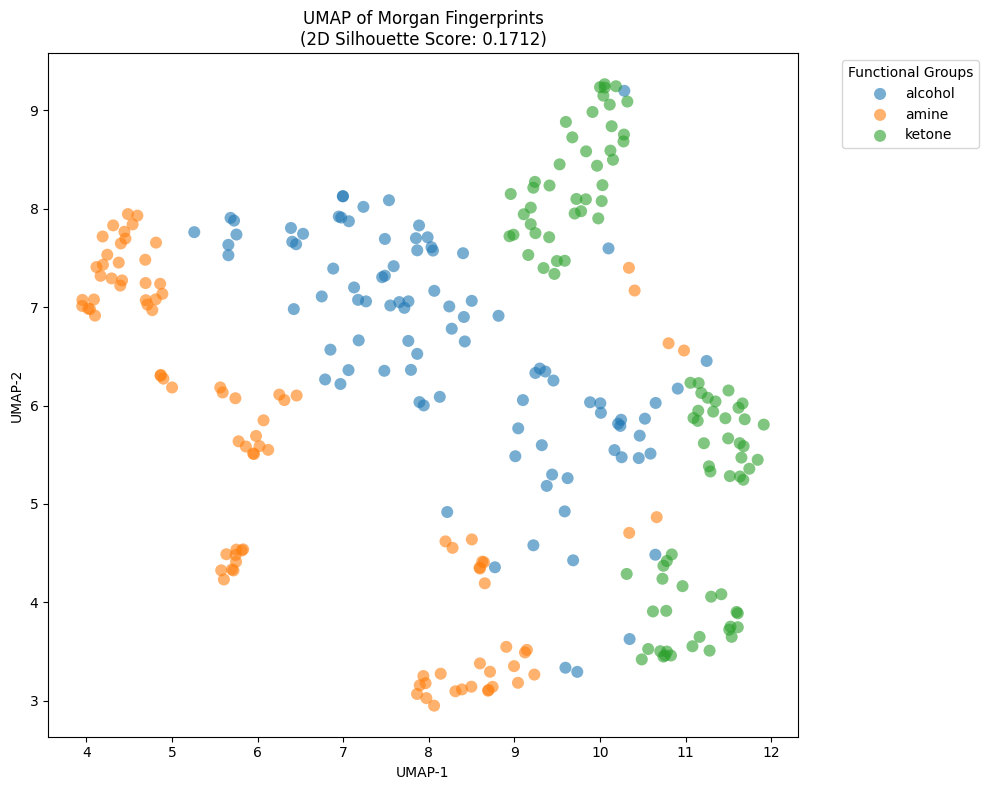

In [21]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from umap import UMAP

# 1. Native Polars extraction into a 2D NumPy array
print("Extracting Morgan Fingerprints...")
X = np.vstack(df_exp2["morgan_fingerprint"].to_numpy()).astype(bool)  # Cast to bool for optimal Jaccard calculations
labels = df_exp2["functional_groups"].to_list()

# CRITICAL NOTE: We intentionally skip StandardScaler here. 
# Morgan Fingerprints are binary arrays, and standardizing them breaks the Jaccard distance logic.

print("Running UMAP (Jaccard metric)...")
reducer = UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="jaccard",  # Jaccard is the correct metric for binary bit vectors
    n_jobs=1,          # Prevents multi-threading kernel deadlocks
    random_state=42
)

embedding = reducer.fit_transform(X)

# -------------------------------------------------------------------------
# 2. CALCULATE CLUSTERING NUMBERS (Silhouette Scores)
# -------------------------------------------------------------------------
print("\n--- Latent Space Separation Metrics ---")

# Raw high-dimensional score: Must use 'jaccard' to match the structural representation of fingerprints
score_raw = silhouette_score(X, labels, metric="jaccard")
print(f"Raw Fingerprint Space Silhouette Score (Jaccard): {score_raw:.4f}")

# 2D UMAP score: Uses 'euclidean' because the projection dimensions are spatial coordinates
score_umap = silhouette_score(embedding, labels, metric="euclidean")
print(f"2D UMAP Project Space Silhouette Score (Euclidean): {score_umap:.4f}\n")

# -------------------------------------------------------------------------
# 3. PLOT GENERATION
# -------------------------------------------------------------------------
print("Generating plot...")
plt.figure(figsize=(10, 8))

labels_np = np.array(labels)
unique_groups = sorted(set(labels))

for group in unique_groups:
    mask = (labels_np == group)
    plt.scatter(
        embedding[mask, 0],
        embedding[mask, 1],
        label=group,
        edgecolors='none',
        s=75,
        alpha=0.6
    )

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title(f"UMAP of Morgan Fingerprints\n(2D Silhouette Score: {score_umap:.4f})")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Functional Groups")
plt.tight_layout()
plt.show()

In [ ]:
functional_groups = df_exp2['functional_groups'].to_list()
label_map = {
    "alcohol": 0,
    "amine": 1,
    "ketone": 2
}

functional_groups_to_labels = [
    label_map[fg]
    for fg in functional_groups
]

In [ ]:
create_chemiscope_viewer(df_exp2, dist_matrix, labels=functional_groups_to_labels, reduction_method="UMAP")

2026-05-20 09:51:51.619 | INFO     | src.helper_functions:create_chemiscope_viewer:1163 - Running UMAP dimensionality reduction...
2026-05-20 09:51:51.623 | INFO     | src.helper_functions:create_chemiscope_viewer:1172 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-20 09:51:52.336 | INFO     | src.helper_functions:create_chemiscope_viewer:1212 - Projecting using UMAP with n_neighbours = 15
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
2026-05-20 09:51:52.571 | INFO     | src.helper_

<ChemiscopeWidget(meta={'name': 'QM9 - UMAP Clustering'}, settings={'map': {'x': {'property': 'UMAP_1'}, 'y': …

Analyzing Radius = 1...
Analyzing Radius = 2...
Analyzing Radius = 3...

--- SILHOUETTE SCORES ---
Morgan (Radius 1): 0.1231
Morgan (Radius 2): 0.0808
Morgan (Radius 3): 0.0724


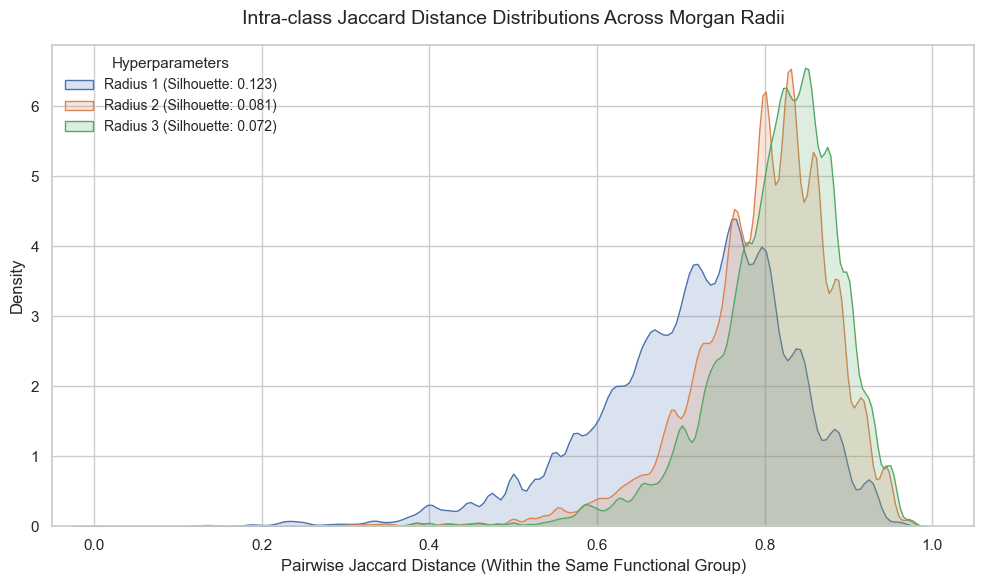

In [ ]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.metrics import pairwise_distances, silhouette_score

# -----------------------------------------------------------------------------
# 1. Setup & Fingerprint Generation Function
# -----------------------------------------------------------------------------
def compute_morgan_bit_vect(smiles: str, radius: int, n_bits: int = 2048) -> np.ndarray:
    """Generates an explicit boolean numpy array for a Morgan Fingerprint."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(n_bits, dtype=np.bool_)
    # Get the ExplicitBitVect object
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    # Efficiently convert to boolean numpy array
    arr = np.zeros((1,), dtype=np.int8)
    Chem.DataStructs.ConvertToNumpyArray(fp, arr)
    return arr.astype(bool)

# Assuming df_exp2 is your filtered Polars DataFrame containing 'smiles' and 'functional_groups'
# Let's extract targets for tracking
labels = df_exp2["functional_groups"].to_numpy()

# Store results for plotting
radii_to_test = [1, 2, 3]
distance_data_by_radius = {}
silhouette_scores = {}

# -----------------------------------------------------------------------------
# 2. Iterative Analysis across Radii
# -----------------------------------------------------------------------------
for r in radii_to_test:
    print(f"Analyzing Radius = {r}...")
    
    # Generate bit vectors for the current radius
    fps = np.array([compute_morgan_bit_vect(s, radius=r) for s in df_exp2["canonical_smiles"]])
    
    # Calculate exact pairwise Jaccard distance matrix
    # Using metric='jaccard' on boolean arrays yields the true Jaccard distance
    dist_matrix = pairwise_distances(fps, metric="jaccard")
    
    # --- Analysis 2: High-Dimensional Silhouette Score ---
    # Evaluates cluster cohesion/separation directly in the Jaccard distance space
    score = silhouette_score(dist_matrix, labels, metric="precomputed")
    silhouette_scores[r] = score
    
    # --- Analysis 1: Collect Intra-class Distances ---
    # Isolate distances between molecules within the exact same functional group
    intra_distances = []
    unique_groups = np.unique(labels)
    
    for group in unique_groups:
        group_indices = np.where(labels == group)[0]
        # Slice the distance matrix to extract the sub-matrix for this group
        group_dist_matrix = dist_matrix[group_indices[:, None], group_indices]
        
        # Extract only the upper triangle (excluding the 0.0 diagonal) to avoid duplication
        triu_indices = np.triu_indices_from(group_dist_matrix, k=1)
        intra_distances.extend(group_dist_matrix[triu_indices])
        
    distance_data_by_radius[r] = intra_distances

# -----------------------------------------------------------------------------
# 3. Visualization and Summary
# -----------------------------------------------------------------------------
print("\n--- SILHOUETTE SCORES ---")
for r, score in silhouette_scores.items():
    print(f"Morgan (Radius {r}): {score:.4f}")

# Plotting the Distance Distributions (KDE)
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

for r in radii_to_test:
    sns.kdeplot(
        distance_data_by_radius[r], 
        label=f"Radius {r} (Silhouette: {silhouette_scores[r]:.3f})", 
        fill=True, 
        alpha=0.2,
        bw_adjust=0.5
    )

plt.title("Intra-class Jaccard Distance Distributions Across Morgan Radii", fontsize=14, pad=15)
plt.xlabel("Pairwise Jaccard Distance (Within the Same Functional Group)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.xlim(-0.05, 1.05)
plt.legend(title="Hyperparameters", fontsize=10, title_fontsize=11)
plt.tight_layout()
plt.show()

Computing UMAP for Radius = 1...


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Computing UMAP for Radius = 2...


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Computing UMAP for Radius = 3...


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


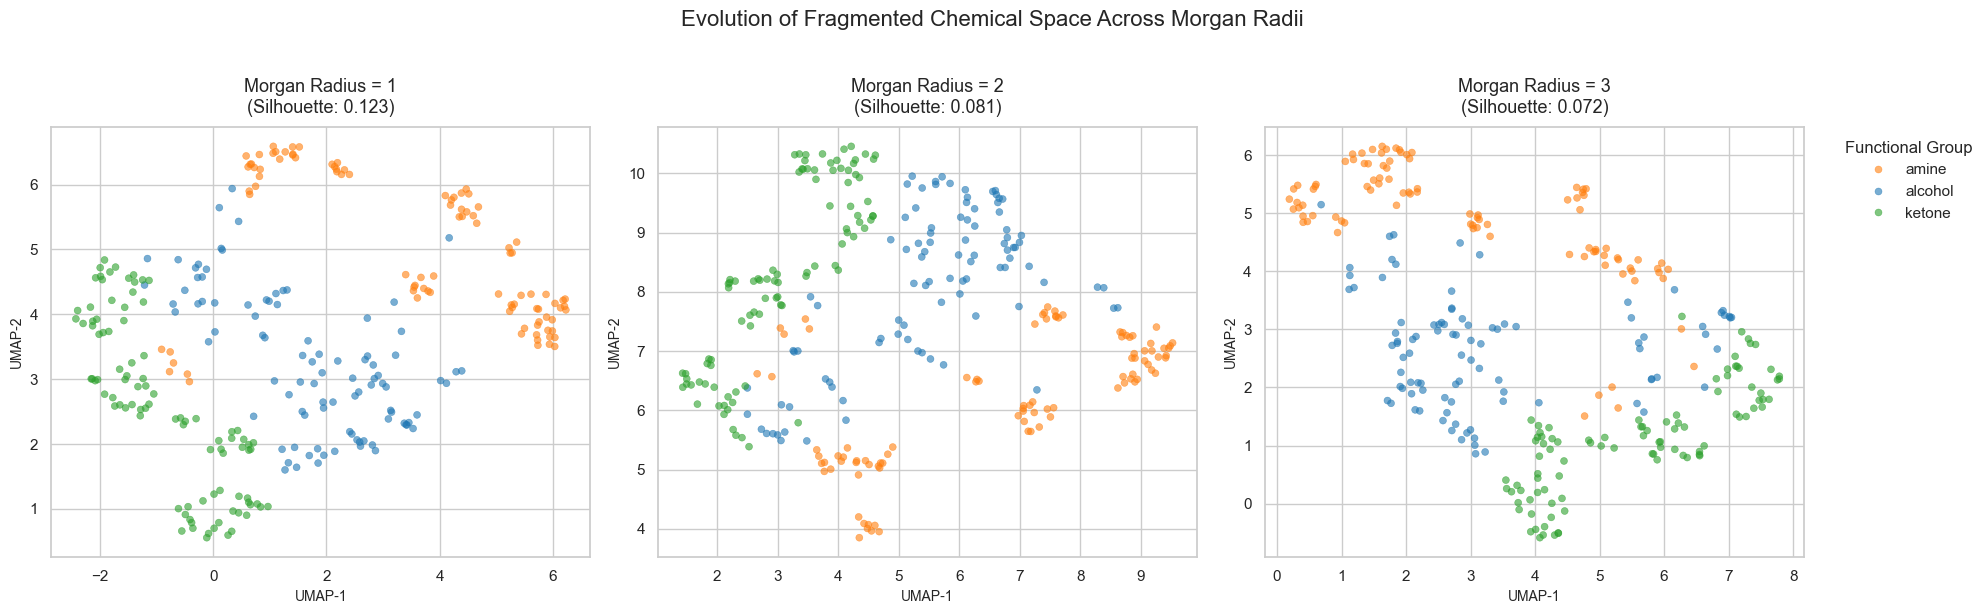

In [ ]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.metrics import pairwise_distances, silhouette_score

# -----------------------------------------------------------------------------
# 1. Setup & Fingerprint Generation Function
# -----------------------------------------------------------------------------
def compute_morgan_bit_vect(smiles: str, radius: int, n_bits: int = 2048) -> np.ndarray:
    """Generates an explicit boolean numpy array for a Morgan Fingerprint."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(n_bits, dtype=np.bool_)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    arr = np.zeros((1,), dtype=np.int8)
    Chem.DataStructs.ConvertToNumpyArray(fp, arr)
    return arr.astype(bool)

# Extract targets for tracking and coloring
labels = df_exp2["functional_groups"].to_numpy()
radii_to_test = [1, 2, 3]

# Initialize the side-by-side matplotlib figure (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=False, sharey=False)
sns.set_theme(style="whitegrid")

# Define a stable color palette for consistency across subplots
unique_labels = sorted(list(np.unique(labels)))
palette = dict(zip(unique_labels, sns.color_palette("tab10", len(unique_labels))))

# -----------------------------------------------------------------------------
# 2. Iterative UMAP Generation and Plotting
# -----------------------------------------------------------------------------
for idx, r in enumerate(radii_to_test):
    print(f"Computing UMAP for Radius = {r}...")
    ax = axes[idx]
    
    # 2.1 Generate fingerprints and Jaccard matrix
    fps = np.array([compute_morgan_bit_vect(s, radius=r) for s in df_exp2["canonical_smiles"]])
    dist_matrix = pairwise_distances(fps, metric="jaccard")
    
    # 2.2 Compute Silhouette Score for the subplot title
    score = silhouette_score(dist_matrix, labels, metric="precomputed")
    
    # 2.3 Fit UMAP using the precomputed distance matrix
    reducer = umap.UMAP(
        n_neighbors=15, 
        min_dist=0.1, 
        metric="precomputed", 
        random_state=42
    )
    embedding = reducer.fit_transform(dist_matrix)
    
    # 2.4 Plot the embedding on its designated axis
    sns.scatterplot(
        x=embedding[:, 0],
        y=embedding[:, 1],
        hue=labels,
        palette=palette,
        alpha=0.6,
        edgecolor=None,
        s=25,
        ax=ax,
        legend=(idx == 2) # Only render the legend on the final subplot to save space
    )
    
    # 2.5 Style the individual subplots
    ax.set_title(f"Morgan Radius = {r}\n(Silhouette: {score:.3f})", fontsize=13, pad=10)
    ax.set_xlabel("UMAP-1", fontsize=10)
    ax.set_ylabel("UMAP-2", fontsize=10)

# Move the unified legend to the right of the figure grid
if axes[2].get_legend() is not None:
    axes[2].legend(title="Functional Group", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle("Evolution of Fragmented Chemical Space Across Morgan Radii", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
fps = np.array([compute_morgan_bit_vect(s, radius=1) for s in df_exp2["canonical_smiles"]])
dist_matrix = pairwise_distances(fps, metric="jaccard")
unique_labels
create_chemiscope_viewer(df_exp2, dist_matrix, functional_groups_to_labels, "UMAP")

2026-05-20 10:17:20.524 | INFO     | src.helper_functions:create_chemiscope_viewer:1163 - Running UMAP dimensionality reduction...
2026-05-20 10:17:20.524 | INFO     | src.helper_functions:create_chemiscope_viewer:1172 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-20 10:17:21.200 | INFO     | src.helper_functions:create_chemiscope_viewer:1212 - Projecting using UMAP with n_neighbours = 15
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
2026-05-20 10:17:21.422 | INFO     | src.helper_

<ChemiscopeWidget(meta={'name': 'QM9 - UMAP Clustering'}, settings={'map': {'x': {'property': 'UMAP_1'}, 'y': …

create_chemiscope_vier

--- MORGAN VECTOR MATRIX CHECKS ---
Are standard fingerprints identical? : True


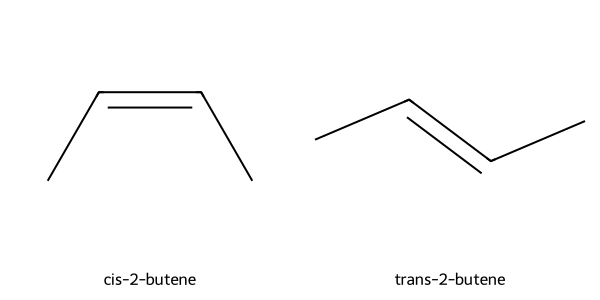

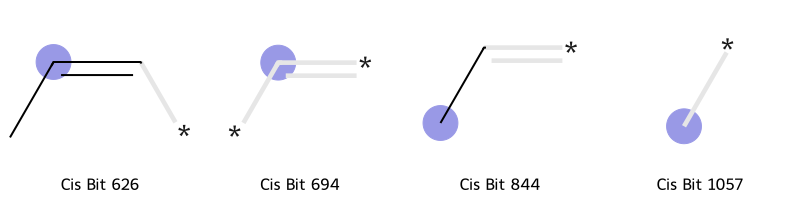

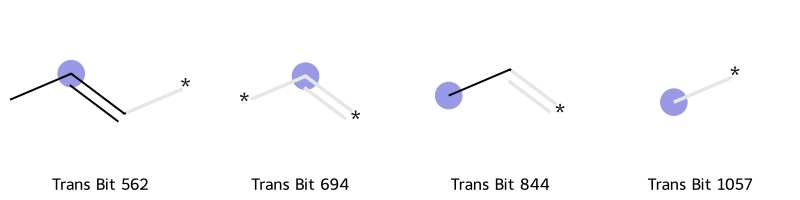

In [33]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw

# -------------------------------------------------------------------------
# 1. SETUP MOLECULES (Fixed SyntaxWarning using raw strings r"...")
# -------------------------------------------------------------------------
cis_smiles = r"C/C=C\C"
trans_smiles = r"C/C=C/C"

mol_cis = Chem.MolFromSmiles(cis_smiles)
mol_trans = Chem.MolFromSmiles(trans_smiles)

# Compute 2D coordinates for clear rendering
AllChem.Compute2DCoords(mol_cis)
AllChem.Compute2DCoords(mol_trans)

# -------------------------------------------------------------------------
# 2. MATRIX CHECKS (Prints directly to your console)
# -------------------------------------------------------------------------
fp_cis_blind = AllChem.GetMorganFingerprintAsBitVect(mol_cis, radius=2, nBits=2048)
fp_trans_blind = AllChem.GetMorganFingerprintAsBitVect(mol_trans, radius=2, nBits=2048)

#fp_cis_aware = AllChem.GetMorganFingerprintAsBitVect(mol_cis, radius=2, nBits=2048, useChirality=True)
#fp_trans_aware = AllChem.GetMorganFingerprintAsBitVect(mol_trans, radius=2, nBits=2048, useChirality=True)

print("--- MORGAN VECTOR MATRIX CHECKS ---")
print(f"Are standard fingerprints identical? : {fp_cis_blind == fp_trans_blind}")
#print(f"Are stereo-aware fingerprints identical?: {fp_cis_aware == fp_trans_aware}\n")

# -------------------------------------------------------------------------
# 3. DISPLAY 2D MOLECULAR STRUCTURES
# -------------------------------------------------------------------------
# Leaving this as the last line of a cell (or assigning it) displays it in Jupyter
img_mols = Draw.MolsToGridImage(
    [mol_cis, mol_trans], 
    molsPerRow=2, 
    subImgSize=(300, 300), 
    legends=["cis-2-butene", "trans-2-butene"]
)
display(img_mols) # Forces display in notebook

# -------------------------------------------------------------------------
# 4. EXTRACT AND NATIVELY DISPLAY BIT SUBSTRUCTURES
# -------------------------------------------------------------------------
bit_info_cis = {}
_ = AllChem.GetMorganFingerprintAsBitVect(mol_cis, radius=2, nBits=2048, bitInfo=bit_info_cis, useChirality=True)

bit_info_trans = {}
_ = AllChem.GetMorganFingerprintAsBitVect(mol_trans, radius=2, nBits=2048, bitInfo=bit_info_trans, useChirality=True)

# Generate structural environment drawings for the cis bits
cis_bits_to_draw = [(mol_cis, bit, bit_info_cis) for bit in list(bit_info_cis.keys())[:4]]
img_cis_bits = Draw.DrawMorganBits(
    cis_bits_to_draw, 
    molsPerRow=4, 
    subImgSize=(200, 200), 
    legends=[f"Cis Bit {b[1]}" for b in cis_bits_to_draw]
)
display(img_cis_bits)

# Generate structural environment drawings for the trans bits
trans_bits_to_draw = [(mol_trans, bit, bit_info_trans) for bit in list(bit_info_trans.keys())[:4]]
img_trans_bits = Draw.DrawMorganBits(
    trans_bits_to_draw, 
    molsPerRow=4, 
    subImgSize=(200, 200), 
    legends=[f"Trans Bit {b[1]}" for b in trans_bits_to_draw]
)
display(img_trans_bits)